In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('/content/sustainability_data.csv')

x= data[['Energy_Consumption', 'Renewable_Percentage', 'GDP']]
y = data['CO2_Emissions']


x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

poly=PolynomialFeatures(degree=2)
x_poly_train=poly.fit_transform(x_train)
x_poly_test=poly.transform(x_test)

In [3]:
model=LinearRegression()
model.fit(x_poly_train, y_train)

LinearRegression()

In [4]:
y_pred=model.predict(x_poly_test)
y_pred

array([ 734.07298491,  874.62164867,  947.22015401,  858.08950479,
       1027.78382866])

In [5]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test, y_pred)
r2=r2_score(y_test,y_pred)
print(f'mean squared error: {mse}')
print(f'R² Score: {r2}')

mean squared error: 2341.1134159353965
R² Score: 0.06978468406875404


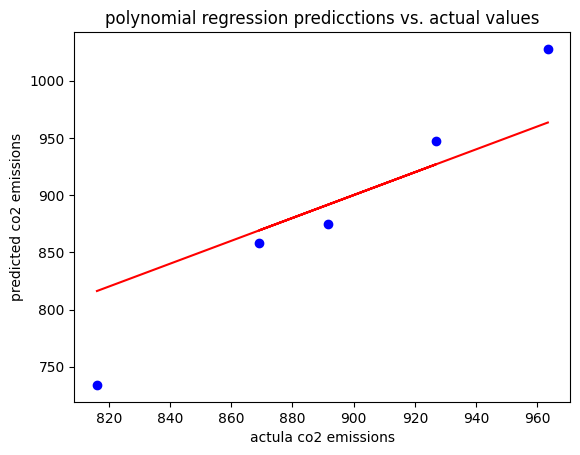

In [6]:
plt.scatter(y_test,y_pred,color='blue')
plt.plot(y_test,y_test,color='red')
plt.xlabel('actula co2 emissions')
plt.ylabel('predicted co2 emissions')
plt.title('polynomial regression predicctions vs. actual values')
plt.show()

In [7]:
import joblib
joblib.dump(model,'ploynomialRegModel.pkl')

['ploynomialRegModel.pkl']

In [8]:
from google.colab import files

files.download('ploynomialRegModel.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>